In [2]:
# =========================
# 1. Import required libraries
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


# =========================
# 2. Load data
# =========================

df = pd.read_csv("/Users/zhanghanjing/Desktop/ENGG212/CleanCoral.csv")

print("Data shape:", df.shape)
print(df.head())

Data shape: (152, 11)
   Distance_to_Shore  Turbidity  Cyclone_Frequency  Depth_m  \
0            8519.23     0.0287              49.90    10.00   
1            1431.62     0.0262              51.20    14.00   
2             182.33     0.0429              61.52     7.00   
3             313.13     0.0424              65.39     9.02   
4             792.00     0.0424              65.39    12.50   

   Percent_Bleaching  Temperature_Kelvin  Windspeed  SSTA  SSTA_Maximum  \
0               50.2              302.05          8 -0.46          2.24   
1               50.7              303.30          2  1.29          3.10   
2               50.9              299.18          8  0.04          2.83   
3               50.9              299.61          3 -0.07          2.47   
4               50.9              299.70          3  0.00          2.30   

   SSTA_Frequency  SSTA_DHW  
0             0.0      0.00  
1             0.5      0.26  
2            16.0      0.00  
3            22.0      0.00 

In [3]:
# =========================
# 3. Convert Percent_Bleaching into classes
# =========================

def bleaching_class(value):
    if value == 0:
        return 0      # No bleaching
    elif value <= 25:
        return 1      # Low bleaching
    elif value <= 50:
        return 2      # Medium bleaching
    else:
        return 3      # High bleaching


df["Bleaching_Class"] = df["Percent_Bleaching"].apply(bleaching_class)

print(df["Bleaching_Class"].value_counts().sort_index())

Bleaching_Class
0     16
1     15
3    121
Name: count, dtype: int64


In [4]:
# =========================
# 4. Define features and target
# =========================

features = [
    "Distance_to_Shore",
    "Turbidity",
    "Cyclone_Frequency",
    "Depth_m",
    "Temperature_Kelvin",
    "Windspeed",
    "SSTA",
    "SSTA_Maximum",
    "SSTA_Frequency",
    "SSTA_DHW"
]

X = df[features]
y = df["Bleaching_Class"]

In [5]:
# =========================
# 5. Split data into training and testing sets
# =========================

Xtrain, Xtest, ytrain, ytest = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
# =========================
# 6. Min-Max normalisation
# =========================

scaler = MinMaxScaler()

Xtrain = scaler.fit_transform(Xtrain)
Xtest = scaler.transform(Xtest)




In [7]:
# =========================
# 7. Define classifier objects
# =========================

K = 9

# KNN: equal weight for all neighbours
neigh1 = KNeighborsClassifier(
    n_neighbors=K,
    weights="uniform"
)

# WNN: closer neighbours have higher weight
neigh2 = KNeighborsClassifier(
    n_neighbors=K,
    weights="distance"
)

In [8]:

# =========================
# 8. Fit the models
# =========================

neigh1.fit(Xtrain, ytrain)
neigh2.fit(Xtrain, ytrain)

KNeighborsClassifier(n_neighbors=9, weights='distance')

In [9]:
# =========================
# 9. Predict using test data
# =========================

yhat1 = neigh1.predict(Xtest)   # KNN prediction
yhat2 = neigh2.predict(Xtest)   # WNN prediction

In [10]:
# =========================
# 10. Evaluate models
# =========================

print("\nKNN Results")
print("-" * 40)
print("Accuracy:", accuracy_score(ytest, yhat1))
print("Precision:", precision_score(ytest, yhat1, average="weighted", zero_division=0))
print("Recall:", recall_score(ytest, yhat1, average="weighted", zero_division=0))
print("F1 Score:", f1_score(ytest, yhat1, average="weighted", zero_division=0))
print("\nClassification Report:")
print(classification_report(ytest, yhat1, zero_division=0))


print("\nWNN Results")
print("-" * 40)
print("Accuracy:", accuracy_score(ytest, yhat2))
print("Precision:", precision_score(ytest, yhat2, average="weighted", zero_division=0))
print("Recall:", recall_score(ytest, yhat2, average="weighted", zero_division=0))
print("F1 Score:", f1_score(ytest, yhat2, average="weighted", zero_division=0))
print("\nClassification Report:")
print(classification_report(ytest, yhat2, zero_division=0))


KNN Results
----------------------------------------
Accuracy: 0.9032258064516129
Precision: 0.816820276497696
Recall: 0.9032258064516129
F1 Score: 0.8575776019476568

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       0.00      0.00      0.00         3
           3       0.89      1.00      0.94        25

    accuracy                           0.90        31
   macro avg       0.63      0.67      0.65        31
weighted avg       0.82      0.90      0.86        31


WNN Results
----------------------------------------
Accuracy: 0.9354838709677419
Precision: 0.94026284348865
Recall: 0.9354838709677419
F1 Score: 0.9205955334987593

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      0.33      0.50         3
           3       0.93      1.00      0.96        25

    accuracy      

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd

results = pd.DataFrame({
    "Model": ["KNN", "WNN"],
    "Accuracy": [
        accuracy_score(ytest, yhat1),
        accuracy_score(ytest, yhat2)
    ],
    "Precision": [
        precision_score(ytest, yhat1, average="weighted", zero_division=0),
        precision_score(ytest, yhat2, average="weighted", zero_division=0)
    ],
    "Recall": [
        recall_score(ytest, yhat1, average="weighted", zero_division=0),
        recall_score(ytest, yhat2, average="weighted", zero_division=0)
    ],
    "F1 Score": [
        f1_score(ytest, yhat1, average="weighted", zero_division=0),
        f1_score(ytest, yhat2, average="weighted", zero_division=0)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,0.903226,0.816820,0.903226,0.857578
1,WNN,0.935484,0.940263,0.935484,0.920596


In [12]:
# =========================
# 11. Confusion matrices
# =========================

print("\nKNN Confusion Matrix:")
print(confusion_matrix(ytest, yhat1))

print("\nWNN Confusion Matrix:")
print(confusion_matrix(ytest, yhat2))


KNN Confusion Matrix:
[[ 3  0  0]
 [ 0  0  3]
 [ 0  0 25]]

WNN Confusion Matrix:
[[ 3  0  0]
 [ 0  1  2]
 [ 0  0 25]]


In [13]:
# =========================
# 12. Try different K values
# =========================

k_values = [3, 5, 7, 9, 11, 15, 21, 31]

results = []

for K in k_values:
    knn = KNeighborsClassifier(n_neighbors=K, weights="uniform")
    wnn = KNeighborsClassifier(n_neighbors=K, weights="distance")

    knn.fit(Xtrain, ytrain)
    wnn.fit(Xtrain, ytrain)

    knn_pred = knn.predict(Xtest)
    wnn_pred = wnn.predict(Xtest)

    results.append({
        "K": K,
        "KNN_Accuracy": accuracy_score(ytest, knn_pred),
        "WNN_Accuracy": accuracy_score(ytest, wnn_pred),
        "KNN_F1": f1_score(ytest, knn_pred, average="weighted", zero_division=0),
        "WNN_F1": f1_score(ytest, wnn_pred, average="weighted", zero_division=0)
    })

results_df = pd.DataFrame(results)
print("\nK comparison:")
print(results_df)


K comparison:
    K  KNN_Accuracy  WNN_Accuracy    KNN_F1    WNN_F1
0   3      0.838710      0.838710  0.848585  0.848585
1   5      0.838710      0.870968  0.824162  0.870968
2   7      0.838710      0.870968  0.824162  0.870968
3   9      0.903226      0.935484  0.857578  0.920596
4  11      0.903226      0.903226  0.857578  0.857578
5  15      0.870968      0.903226  0.824134  0.857578
6  21      0.838710      0.870968  0.781525  0.824134
7  31      0.806452      0.870968  0.720046  0.824134


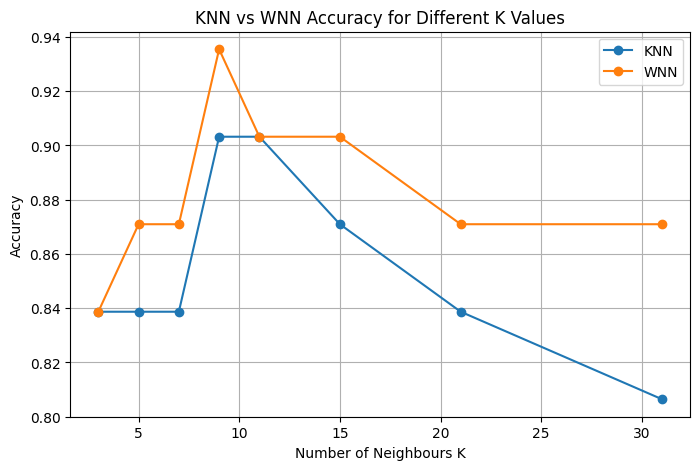

In [14]:
# =========================
# 13. Plot accuracy comparison
# =========================

plt.figure(figsize=(8, 5))
plt.plot(results_df["K"], results_df["KNN_Accuracy"], marker="o", label="KNN")
plt.plot(results_df["K"], results_df["WNN_Accuracy"], marker="o", label="WNN")
plt.xlabel("Number of Neighbours K")
plt.ylabel("Accuracy")
plt.title("KNN vs WNN Accuracy for Different K Values")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# =========================
# 14. Save prediction results
# =========================

output = pd.DataFrame({
    "Actual_Class": ytest,
    "KNN_Predicted_Class": yhat1,
    "WNN_Predicted_Class": yhat2
})

output.to_csv("coral_knn_wnn_classification_results.csv", index=False)

print("\nResults saved as coral_knn_wnn_classification_results.csv")


Results saved as coral_knn_wnn_classification_results.csv
